# Problem Statement



<html> <font color = Darkblue>
The purpose is to predict whether the Pima Indian women shows signs of diabetes or not. We are using a dataset collected by "National Institute of Diabetes and Digestive and Kidney Diseases" which consists of a number of attributes which would help us to perform this prediction.
</font>
</html>

<html>
<font color = blue>
<b>Constraints on data collection </b>

</font>
</html>

<html> <font color = Darkblue>
All patients whose data has been collected are females at least 21 years old of Pima Indian heritage
</font>
</html>

In [1]:
#Import all the necessary modules
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from scipy.stats import zscore
from sklearn.preprocessing import Imputer
from sklearn import metrics
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import VotingClassifier


from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
# importing ploting libraries
import matplotlib.pyplot as plt   
#importing seaborn for statistical plots
import seaborn as sns
# To enable plotting graphs in Jupyter notebook
%matplotlib inline 

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc

# Q1. Load the PIMA Indian Diabetes file into Python DataFrame. 


The file can be accessed directly from the URL (https://archive.ics.uci.edu/ml/machine-learning-databases/pima-indians-diabetes/pima-indians-diabetes.data or you may first download it to a local folder and then load it into Python dataframe.  Let us assume the data frame is named pima_df


In [2]:
colnames = ['preg', 'plas', 'pres', 'skin', 'insulin', 'bmi', 'pedi', 'age', 'class']

pima_df = pd.read_csv("pima-indians-diabetes.data", names= colnames)


It is always a good practice to eye-ball raw data to get a feel of the data in terms of number of structure of the file, number of attributes, types of attributes and a general idea of likely challenges in the dataset. You would notice that it is a comma separated file. There are no column names!. Check the associated folders and find out about each attribute the name. What information is available about the data.

# Q2. Print 10 samples from the dataset

In [3]:
pima_df.head(10)

,preg,plas,pres,skin,insulin,bmi,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


# Q3 Print the datatypes of each column and the shape of the dataset 

In [4]:
print("Shape of the data ",pima_df.shape)
print("Info of the data ")
pima_df.info()

pima_df_des=pima_df.describe()
pima_df_des


Shape of the data  (768, 9)
Info of the data 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
preg       768 non-null int64
plas       768 non-null int64
pres       768 non-null int64
skin       768 non-null int64
insulin    768 non-null int64
bmi        768 non-null float64
pedi       768 non-null float64
age        768 non-null int64
class      768 non-null int64
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,preg,plas,pres,skin,insulin,bmi,pedi,age,class
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


There are '0's in the data. Are they really valid '0's or they are missing values?
Plasma, BP, skin thickness etc. these values cannot be 0.
look at column by column logically to understand this.

# Q4 Replace all the 0s in the column with the median of the same column value accordingly.

In [5]:

pima_df['plas'] = pima_df['plas'].replace({0: np.median(pima_df['plas'])})
pima_df['pres'] = pima_df['pres'].replace({0: np.median(pima_df['pres'])})
pima_df['skin'] = pima_df['skin'].replace({0: np.median(pima_df['skin'])})
pima_df['insulin'] = pima_df['insulin'].replace({0: np.median(pima_df['insulin'])})
pima_df['bmi'] = pima_df['bmi'].replace({0: np.median(pima_df['bmi'])})

# Q5 Print the descriptive statistics of each & every column using describe() function

In [6]:
pima_df.describe()

,preg,plas,pres,skin,insulin,bmi,pedi,age,class
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,27.334635,94.652344,32.450911,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,9.229014,105.547598,6.875366,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,23.000000,30.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,31.250000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# Q6 See the distribution of 'Class' variable and plot it using appropriate graph.

<BarContainer object of 2 artists>

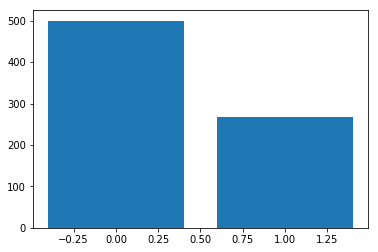

In [7]:
class_dis=pima_df["class"].value_counts()

plt.bar([0,1],class_dis)


#Just for your understanding - Using univariate analysis check the individual attributes for their basic statistic such as central values, spread, tails etc. What are your observations (any two attributes). Its an optional step and will not be graded.

# Q7. Use pairplots and correlation method to observe the relationship between different variables and state your insights.
Hint: Use seaborn plot and check the relationship between different variables 


Using the plot - infer the relationship between different variables

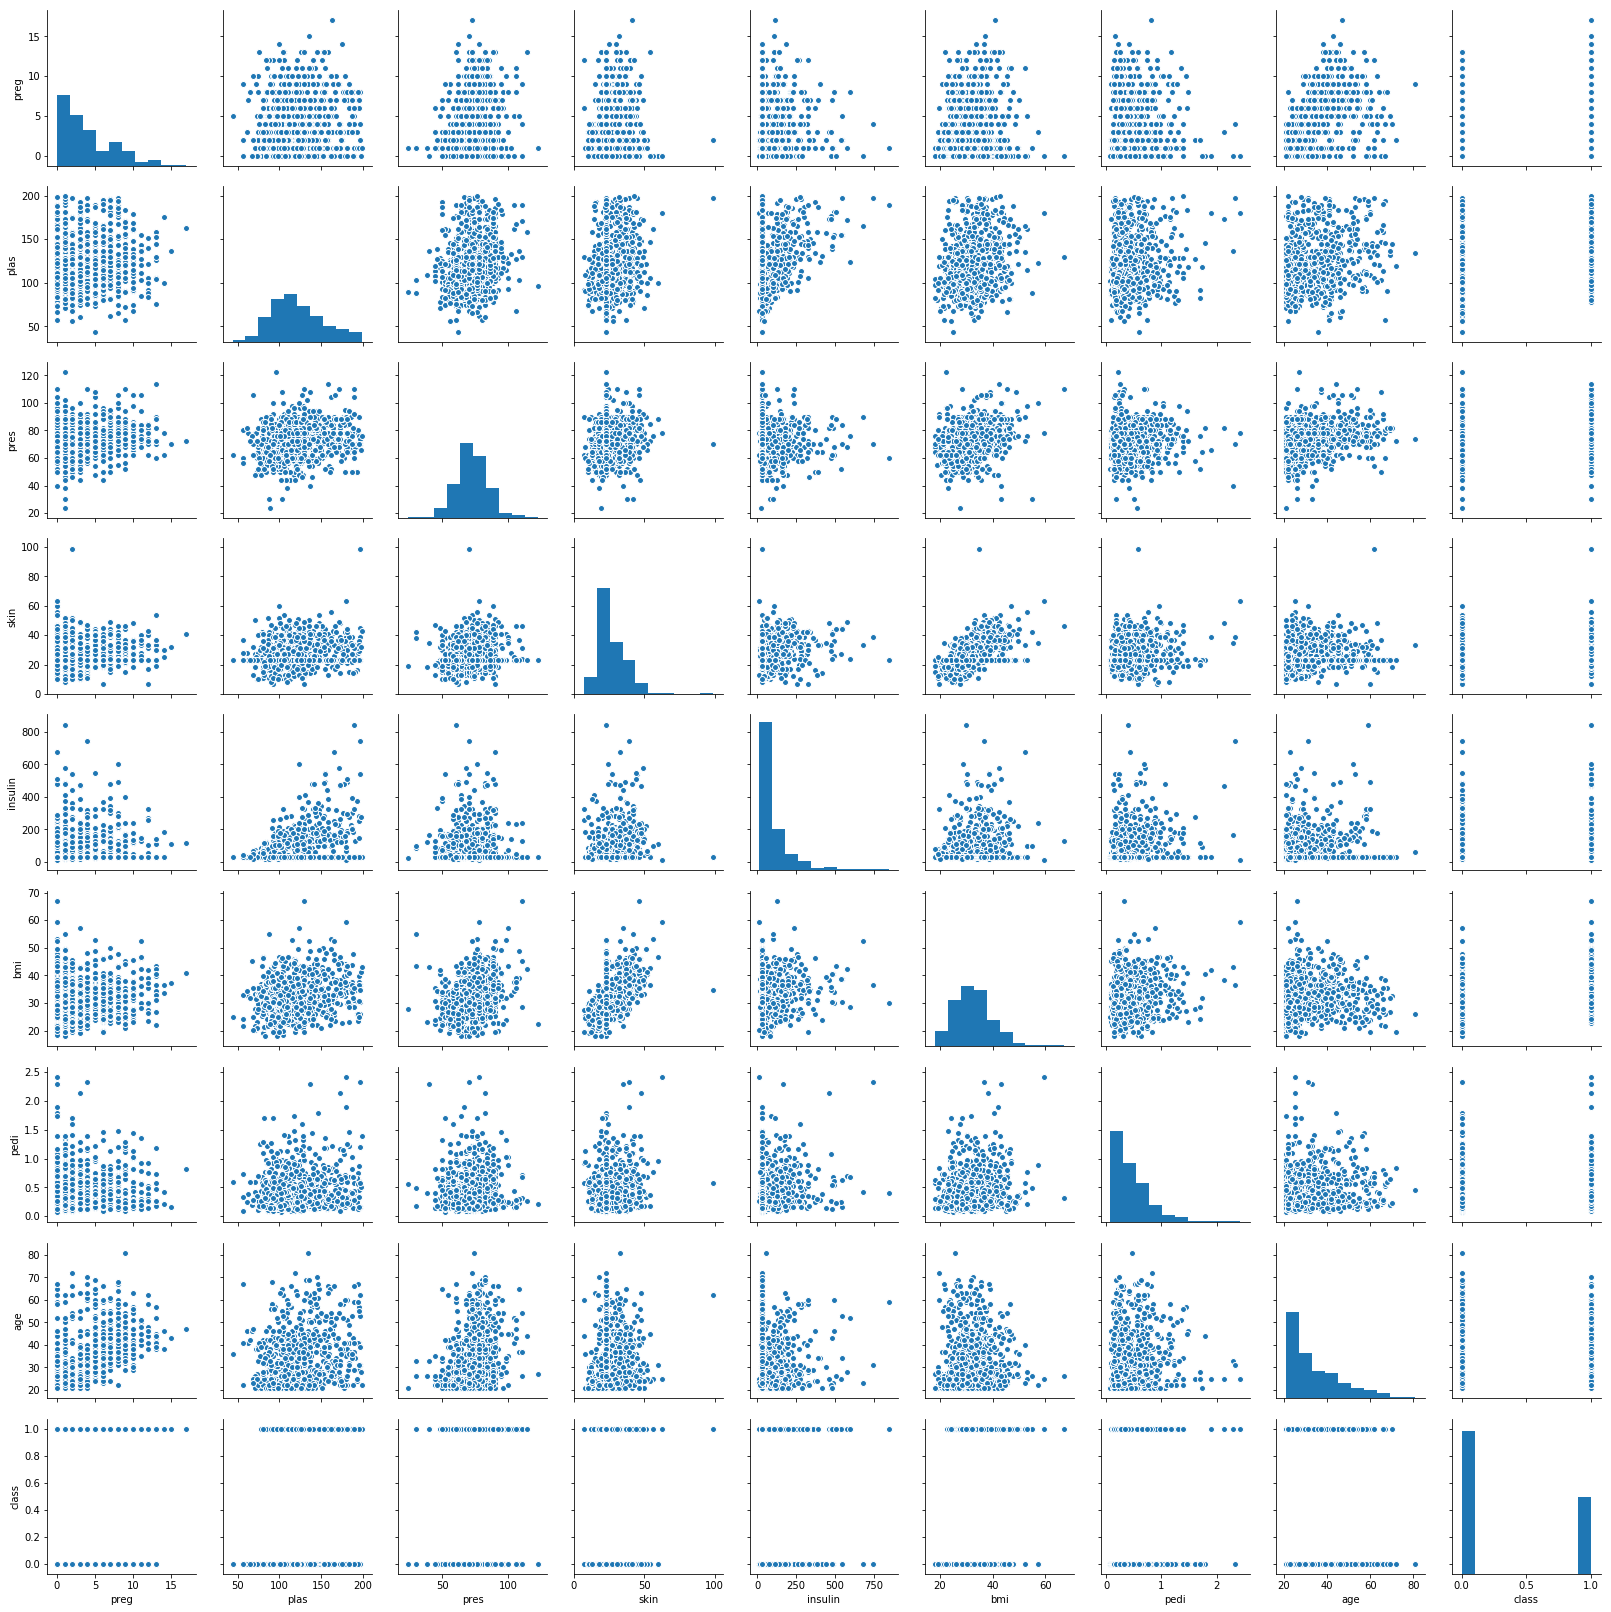

In [8]:
sns.pairplot(pima_df)

# 1. Skin Thickness, inslulin, Age, pedigree are all Right Skewed
# 2. Skin thinkness and BMI are correlated
# 3. Insulin and blood Plasma are correlated

# Q8 Split the pima_df into training and test set in the ratio of 70:30 (Training:Test).</b>


In [9]:
X = pima_df.drop("class", axis=1)
y = pima_df["class"]

test_size = 0.30 # taking 70:30 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

# Q9 Create the decision tree model using “entropy” method of reducing the entropy and fit it to training data.</b>



In [10]:
Xtrain=np.array(X_train)
Ytrain=np.array(y_train)

Xtest=np.array(X_test)
Ytest=np.array(y_test)

In [11]:
model1=DecisionTreeClassifier(random_state=0)
model1.fit(Xtrain,Ytrain)

#Perform Grid Search Method to find the optimal max_depth size
from sklearn.model_selection import GridSearchCV
parameter={'max_depth':np.arange(1,10),'criterion' : ['entropy','gini']}
GS=GridSearchCV(model1,parameter,cv=3)
GS.fit(X,y)
GS.score(Xtrain,Ytrain)
GS.best_params_

DecisionTreeClassifier(class_weight=None, criterion='gini', max_depth=None,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=0,
            splitter='best')

GridSearchCV(cv=3, error_score='raise',
       estimator=DecisionTreeClassifier(class_weight=None, criterion='gini', max_depth=None,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=0,
            splitter='best'),
       fit_params=None, iid=True, n_jobs=1,
       param_grid={'max_depth': array([1, 2, 3, 4, 5, 6, 7, 8, 9]), 'criterion': ['entropy', 'gini']},
       pre_dispatch='2*n_jobs', refit=True, return_train_score='warn',
       scoring=None, verbose=0)

0.8007448789571695

{'criterion': 'entropy', 'max_depth': 4}

In [12]:
model1=DecisionTreeClassifier(max_depth=4,criterion='entropy',random_state=0)
model1.fit(Xtrain,Ytrain)
model1.score(Xtrain,Ytrain)

DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=4,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=0,
            splitter='best')

0.7951582867783985

# Q10 Print the accuracy of the model & print the confusion matrix 

In [14]:
ypred_dt=model1.predict(Xtest)

print("********* Confusion Matrix **********")
metrics.confusion_matrix(Ytest,ypred_dt)

print("Accuracy score of Test data ",model1.score(Xtest,Ytest) )

pd.DataFrame(data=[accuracy_score(Ytest, ypred_dt),recall_score(Ytest, ypred_dt),
                            precision_score(Ytest, ypred_dt),
                            f1_score(Ytest, ypred_dt)],
                      index=["accuracy", "recall", "precision", "f1_score"])

********* Confusion Matrix **********


array([[106,  41],
       [ 21,  63]], dtype=int64)

Accuracy score of Test data  0.7316017316017316


,0
accuracy,0.731602
recall,0.750000
precision,0.605769
f1_score,0.670213


Print the feature importance of the decision model - Optional

In [15]:
model1.feature_importances_

array([0.02817155, 0.5070506 , 0.        , 0.01689752, 0.        ,
       0.25005882, 0.05111347, 0.14670804])

# Q12 Apply the Random forest model and print the accuracy of Random forest Model

In [16]:
Rf_model = RandomForestClassifier(random_state=0 )
parameter={'n_estimators':np.arange(1,60),'criterion' : ['entropy','gini']}
GS=GridSearchCV(Rf_model,parameter,cv=3)
GS.fit(X,y)
GS.best_params_

GridSearchCV(cv=3, error_score='raise',
       estimator=RandomForestClassifier(bootstrap=True, class_weight=None, criterion='gini',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=10, n_jobs=1,
            oob_score=False, random_state=0, verbose=0, warm_start=False),
       fit_params=None, iid=True, n_jobs=1,
       param_grid={'n_estimators': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59]), 'criterion': ['entropy', 'gini']},
       pre_dispatch='2*n_jobs', refit=True, return_train_score='warn',
       scoring=None, verbose=0)

{'criterion': 'entropy', 'n_estimators': 48}

In [17]:
Rf_model = RandomForestClassifier(n_estimators=48,criterion='entropy',random_state=0 )

In [18]:
Rf_model.fit(Xtrain,Ytrain)
Rf_model.score(Xtrain,Ytrain)

Rf_model.score(Xtest,Ytest)
ypred=Rf_model.predict(Xtest)

results= pd.DataFrame(data=[accuracy_score(Ytest, ypred),recall_score(Ytest, ypred),
                            precision_score(Ytest, ypred),
                            f1_score(Ytest, ypred)],
                      index=["accuracy", "recall", "precision", "f1_score"])
results

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='entropy',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=48, n_jobs=1,
            oob_score=False, random_state=0, verbose=0, warm_start=False)

0.9981378026070763

0.7489177489177489

,0
accuracy,0.748918
recall,0.583333
precision,0.680556
f1_score,0.628205


# Q13 Apply Adaboost Ensemble Algorithm for the same data and print the accuracy.

In [19]:
# Boosting on Desicion Tree model

boost_dt=AdaBoostClassifier(base_estimator=model1,n_estimators=61,random_state=0)

In [20]:
boost_dt.fit(Xtrain,Ytrain)

boost_dt.score(Xtrain,Ytrain)
boost_dt.score(Xtest,Ytest)

ypred_boost=boost_dt.predict(Xtest)

results1= pd.DataFrame(data=[accuracy_score(Ytest, ypred_boost),recall_score(Ytest, ypred_boost),
                            precision_score(Ytest, ypred_boost),
                            f1_score(Ytest, ypred_boost)],
                      index=["accuracy", "recall", "precision", "f1_score"])
results1

AdaBoostClassifier(algorithm='SAMME.R',
          base_estimator=DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=4,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=0,
            splitter='best'),
          learning_rate=1.0, n_estimators=61, random_state=0)

1.0

0.70995670995671

,0
accuracy,0.709957
recall,0.595238
precision,0.602410
f1_score,0.598802


# Q14 - Apply Bagging Classifier Algorithm and print the accuracy.

In [21]:
# Bagging on Descision tree model

bagg_dt=BaggingClassifier(base_estimator=model1,n_estimators=20,random_state=0)

In [22]:
bagg_dt.fit(Xtrain,Ytrain)

bagg_dt.score(Xtrain,Ytrain)
bagg_dt.score(Xtest,Ytest)

ypred_bagg=bagg_dt.predict(Xtest)

results1= pd.DataFrame(data=[accuracy_score(Ytest, ypred_bagg),recall_score(Ytest, ypred_bagg),
                            precision_score(Ytest, ypred_bagg),
                            f1_score(Ytest, ypred_bagg)],
                      index=["accuracy", "recall", "precision", "f1_score"])
results1

BaggingClassifier(base_estimator=DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=4,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=0,
            splitter='best'),
         bootstrap=True, bootstrap_features=False, max_features=1.0,
         max_samples=1.0, n_estimators=20, n_jobs=1, oob_score=False,
         random_state=0, verbose=0, warm_start=False)

0.8286778398510242

0.7532467532467533

,0
accuracy,0.753247
recall,0.642857
precision,0.666667
f1_score,0.654545


# Q15 - Apply GradientBoost Classifier Algorithm for the same data and print the accuracy

In [44]:
gb_model=GradientBoostingClassifier(n_estimators=35,random_state=2)

In [45]:
from sklearn.model_selection import KFold
from sklearn.metrics import roc_curve, auc
kf=KFold(n_splits=5,shuffle=True,random_state=2)

roc_auc=[]
for train,test in kf.split(X,y):
    Xtrain, Xtest=X.loc[train,:], X.loc[test,:]
    Ytrain,Ytest=y.loc[train],y.loc[test]
    gb_model.fit(Xtrain,Ytrain)
    Y_predict=gb_model.predict(Xtest)
    cm=metrics.confusion_matrix(Ytest,Y_predict)
    fpr,tpr, _ = roc_curve(Ytest,Y_predict)
    roc_auc.append(auc(fpr, tpr))





GradientBoostingClassifier(criterion='friedman_mse', init=None,
              learning_rate=0.1, loss='deviance', max_depth=3,
              max_features=None, max_leaf_nodes=None,
              min_impurity_decrease=0.0, min_impurity_split=None,
              min_samples_leaf=1, min_samples_split=2,
              min_weight_fraction_leaf=0.0, n_estimators=35,
              presort='auto', random_state=2, subsample=1.0, verbose=0,
              warm_start=False)

GradientBoostingClassifier(criterion='friedman_mse', init=None,
              learning_rate=0.1, loss='deviance', max_depth=3,
              max_features=None, max_leaf_nodes=None,
              min_impurity_decrease=0.0, min_impurity_split=None,
              min_samples_leaf=1, min_samples_split=2,
              min_weight_fraction_leaf=0.0, n_estimators=35,
              presort='auto', random_state=2, subsample=1.0, verbose=0,
              warm_start=False)

GradientBoostingClassifier(criterion='friedman_mse', init=None,
              learning_rate=0.1, loss='deviance', max_depth=3,
              max_features=None, max_leaf_nodes=None,
              min_impurity_decrease=0.0, min_impurity_split=None,
              min_samples_leaf=1, min_samples_split=2,
              min_weight_fraction_leaf=0.0, n_estimators=35,
              presort='auto', random_state=2, subsample=1.0, verbose=0,
              warm_start=False)

GradientBoostingClassifier(criterion='friedman_mse', init=None,
              learning_rate=0.1, loss='deviance', max_depth=3,
              max_features=None, max_leaf_nodes=None,
              min_impurity_decrease=0.0, min_impurity_split=None,
              min_samples_leaf=1, min_samples_split=2,
              min_weight_fraction_leaf=0.0, n_estimators=35,
              presort='auto', random_state=2, subsample=1.0, verbose=0,
              warm_start=False)

GradientBoostingClassifier(criterion='friedman_mse', init=None,
              learning_rate=0.1, loss='deviance', max_depth=3,
              max_features=None, max_leaf_nodes=None,
              min_impurity_decrease=0.0, min_impurity_split=None,
              min_samples_leaf=1, min_samples_split=2,
              min_weight_fraction_leaf=0.0, n_estimators=35,
              presort='auto', random_state=2, subsample=1.0, verbose=0,
              warm_start=False)

In [46]:
print("AUC scores: %0.02f (+/- %0.5f) [%s]" % (np.mean(roc_auc), np.var(roc_auc,ddof=1), 'Gradient Boost' )) 

AUC scores: 0.70 (+/- 0.00139) [Gradient Boost]


# Next steps are optional and will not be graded.

Voting is one of the simplest ways of combining the predictions from multiple machine learning algorithms.

It works by first creating two or more standalone models from your training dataset. A Voting Classifier can then be used to wrap your models and average the predictions of the sub-models when asked to make predictions for new data.

Apply Voting Classfier on the given dataset and state your insights.